# Data Quality Assessment & Cleaning — CustomerDemographic

**Table:** `CustomerDemographic` — 4,000 existing customers of Sprocket Central Pty Ltd.

This notebook assesses the quality of the customer demographics table, documents every
problem found, fixes it, and exports a cleaned file for the analysis stage.

Each issue below follows the same shape: **what is wrong → why it matters → what was done**.
The rule throughout is that no record is dropped without saying so and no value is imputed
without a reason.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# The whole workbook is one file with four sheets.
df = pd.read_excel('Raw_data.xlsx', sheet_name='CustomerDemographic')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

4,000 rows x 13 columns


,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure
0,1,Laraine,Medendorp,F,93,1953-10-12 00:00:00,Executive Secretary,Health,Mass Customer,N,"""'",Yes,11.0
1,2,Eli,Bockman,Male,81,1980-12-16 00:00:00,Administrative Officer,Financial Services,Mass Customer,N,<script>alert('hi')</script>,Yes,16.0
2,3,Arlin,Dearle,Male,61,1954-01-20 00:00:00,Recruiting Manager,Property,Mass Customer,N,2018-02-01 00:00:00,Yes,15.0
3,4,Talbot,NaN,Male,33,1961-10-03 00:00:00,NaN,IT,Mass Customer,N,() { _; } >_[$($())] { touch /tmp/blns.shellsh...,No,7.0
4,5,Sheila-kathryn,Calton,Female,56,1977-05-13 00:00:00,Senior Editor,NaN,Affluent Customer,N,NIL,Yes,8.0


## 1. First look

Before fixing anything, establish what is here: the columns, their types, and how
complete each one is.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   first_name                           4000 non-null   object 
 2   last_name                            3875 non-null   object 
 3   gender                               4000 non-null   object 
 4   past_3_years_bike_related_purchases  4000 non-null   int64  
 5   DOB                                  3913 non-null   object 
 6   job_title                            3494 non-null   object 
 7   job_industry_category                3344 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  default                              3698 non-null   object 
 11  owns_car                      

In [3]:
# Completeness per column, worst first.
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({
    'missing': missing,
    'pct': (100 * missing / len(df)).round(2)
})

,missing,pct
job_industry_category,656,16.40
job_title,506,12.65
default,302,7.55
last_name,125,3.12
DOB,87,2.17
tenure,87,2.17


Six columns carry missing values. `job_industry_category` is the worst at 16.4%, which is
too much to drop and too much to invent — it is handled as its own category below.

## 2. Issue: the `default` column is junk

The column named `default` holds no customer information at all. Looking at its contents
shows why it can be dropped without losing anything.

In [4]:
df['default'].dropna().unique()[:8]

array(['"\'', "<script>alert('hi')</script>",
       datetime.datetime(2018, 2, 1, 0, 0),
       '() { _; } >_[$($())] { touch /tmp/blns.shellshock2.fail; }',
       'NIL', 'ðµ ð ð ð', 'â°â´âµâââ', '(â¯Â°â¡Â°ï¼â¯ï¸µ â»ââ»)'],
      dtype=object)

These are strings from the **Big List of Naughty Strings** — a standard test set used to
check whether a system breaks on hostile input. The column contains script tags, shell
injection payloads and stray punctuation.

It is test data left in a production extract, not a customer attribute.

**Action:** drop the column.

In [5]:
df = df.drop(columns=['default'])
print(f'dropped. {df.shape[1]} columns remain')

dropped. 12 columns remain


## 3. Issue: gender is not standardised

The same value is recorded several different ways, which would split one group into many
in every chart and every segment count.

In [6]:
df['gender'].value_counts(dropna=False)

gender
Female    2037
Male      1872
U           88
F            1
Femal        1
M            1
Name: count, dtype: int64

Six distinct values for what should be two or three. `F` and `Femal` are Female;
`M` is Male. `U` is 88 records of genuinely unknown gender.

**Action:** map the variants onto their true value. `U` is kept as `Unknown` rather than
guessed or dropped — it is 2.2% of customers and inventing a gender for them would put
made-up data into every downstream chart.

In [7]:
gender_map = {
    'F': 'Female', 'Femal': 'Female', 'Female': 'Female',
    'M': 'Male',   'Male': 'Male',
    'U': 'Unknown',
}
df['gender'] = df['gender'].map(gender_map)
df['gender'].value_counts(dropna=False)

gender
Female     2039
Male       1873
Unknown      88
Name: count, dtype: int64

## 4. Issue: `DOB` has mixed types and an impossible value

The column is read as a mixture of datetimes and strings, so it cannot be sorted or
measured until it is coerced to one type.

In [8]:
print('types present:', set(type(v).__name__ for v in df['DOB'].dropna()))

df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
print('after coercion:', df['DOB'].dtype)
print('missing DOB:', df['DOB'].isna().sum())

types present: {'datetime', 'str'}
after coercion: datetime64[ns]
missing DOB: 87


### Derive Age and Age Group

Age is measured as at **2017-12-31**, the end of the transaction window, so it is stable
rather than drifting every time the notebook is run.

In [9]:
AS_AT = pd.Timestamp('2017-12-31')

df['Age'] = ((AS_AT - df['DOB']).dt.days / 365.25).round().astype('Int64')

bins   = [0, 19, 29, 39, 49, 59, 69, 79, 200]
labels = ['Under 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

df[['Age']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3913.0,40.464094,12.801609,16.0,31.0,40.0,50.0,174.0


The maximum age is **174**, which is not possible. Find the record.

In [10]:
df.nlargest(3, 'Age')[['customer_id', 'first_name', 'DOB', 'Age',
                       'past_3_years_bike_related_purchases']]

,customer_id,first_name,DOB,Age,past_3_years_bike_related_purchases
33,34,Jephthah,1843-12-21,174,59
719,720,Darrel,1931-10-23,86,67
1091,1092,Katlin,1935-08-22,82,56


Customer 34 has a date of birth of **1843-12-21**. The next oldest customer is 86.

This is a single data-entry error, not a real outlier worth keeping — a 174-year-old
would drag the mean age and put a phantom bar in the age distribution.

**Action:** remove the record.

In [11]:
before = len(df)

# .eq(174).fillna(False) rather than != 174: Age is a nullable Int64, so
# NA != 174 evaluates to NA, and boolean indexing silently drops every NA
# row too. Written the obvious way this removed 88 records instead of 1,
# quietly deleting the 87 customers with no date of birth.
df = df[~df['Age'].eq(174).fillna(False)]

print(f'removed {before - len(df)} record. {len(df):,} remain')
print(f"age range now {df['Age'].min()} to {df['Age'].max()}")
print(f"customers with no DOB, kept: {df['Age'].isna().sum()}")

removed 1 record. 3,999 remain
age range now 16 to 86
customers with no DOB, kept: 87


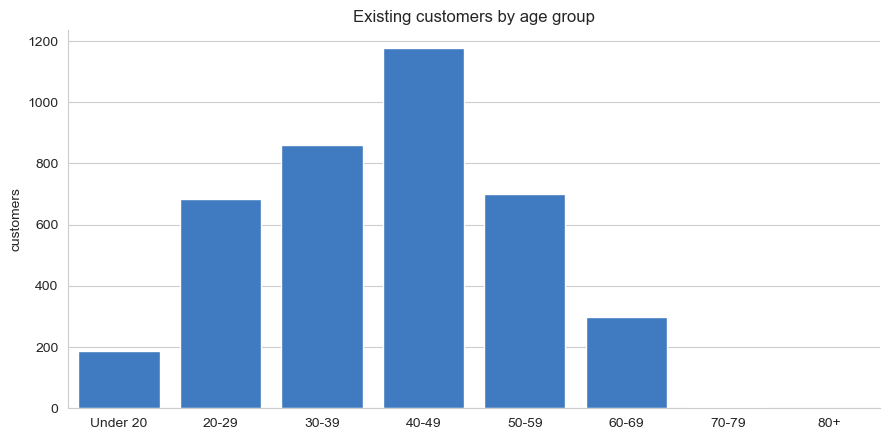

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = [l for l in labels if l in df['Age Group'].dropna().unique()]
sns.countplot(data=df, x='Age Group', order=order, color='#2a78d6', ax=ax)
ax.set_title('Existing customers by age group')
ax.set_xlabel('')
ax.set_ylabel('customers')
sns.despine()
plt.tight_layout()
plt.show()

## 5. Issue: missing values

Each column is handled on its own terms. The volume decides the treatment: a few percent
can be dropped, a sixth of the table cannot.

In [13]:
df[['last_name', 'DOB', 'job_title', 'job_industry_category', 'tenure']].isna().sum()

last_name                125
DOB                       87
job_title                506
job_industry_category    656
tenure                    87
dtype: int64

| Column | Missing | Treatment | Why |
|---|---|---|---|
| `last_name` | 125 (3.1%) | leave | Not used in any analysis. Dropping 125 real customers to fix a field nobody reads would be worse than the gap. |
| `job_title` | 506 (12.7%) | fill `Unknown` | Too many to drop, too varied to impute. |
| `job_industry_category` | 656 (16.4%) | fill `Unknown` | Same, and it appears in the EDA — an explicit `Unknown` bar is honest, a guessed one is not. |
| `DOB` / `Age` | 87 (2.2%) | leave as null | Age is used in charts, which skip nulls. Imputing a birth date invents a customer. |
| `tenure` | 87 (2.2%) | leave as null | Same 87 rows as DOB. |


In [14]:
df['job_title'] = df['job_title'].fillna('Unknown')
df['job_industry_category'] = df['job_industry_category'].fillna('Unknown')

df[['job_title', 'job_industry_category']].isna().sum()

job_title                0
job_industry_category    0
dtype: int64

## 6. Issue: deceased customers are still in the list

The table carries a `deceased_indicator` flag. This project ends in a marketing
recommendation, so a customer who has died cannot be a target.

In [15]:
df['deceased_indicator'].value_counts()

deceased_indicator
N    3997
Y       2
Name: count, dtype: int64

In [16]:
df = df[df['deceased_indicator'] == 'N'].drop(columns=['deceased_indicator'])
print(f'{len(df):,} customers remain after removing deceased records')

3,997 customers remain after removing deceased records


## 7. Check for duplicates

In [17]:
print('fully duplicated rows:', df.duplicated().sum())
print('duplicated customer_id:', df['customer_id'].duplicated().sum())

fully duplicated rows: 0
duplicated customer_id: 0


No duplicates. `customer_id` is unique, so it can be used as the join key to the address
and transaction tables.

## 8. Cleaned output

In [18]:
print(f'{len(df):,} rows x {df.shape[1]} columns')
print()
print('remaining nulls:')
print(df.isna().sum()[df.isna().sum() > 0].to_string())
df.head()

3,997 rows x 13 columns

remaining nulls:
last_name    125
DOB           87
tenure        87
Age           87
Age Group     87


,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,owns_car,tenure,Age,Age Group
0,1,Laraine,Medendorp,Female,93,1953-10-12,Executive Secretary,Health,Mass Customer,Yes,11.0,64,60-69
1,2,Eli,Bockman,Male,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,Yes,16.0,37,30-39
2,3,Arlin,Dearle,Male,61,1954-01-20,Recruiting Manager,Property,Mass Customer,Yes,15.0,64,60-69
3,4,Talbot,NaN,Male,33,1961-10-03,Unknown,IT,Mass Customer,No,7.0,56,50-59
4,5,Sheila-kathryn,Calton,Female,56,1977-05-13,Senior Editor,Unknown,Affluent Customer,Yes,8.0,41,40-49


In [19]:
df.to_csv('CustomerDemographic_Cleaned.csv', index=False)
print('saved CustomerDemographic_Cleaned.csv')

saved CustomerDemographic_Cleaned.csv


## Summary of changes

| # | Issue | Action | Records affected |
|---|---|---|---|
| 1 | `default` column held test-injection strings | dropped the column | all |
| 2 | Gender recorded six different ways | standardised to Female / Male / Unknown | 91 |
| 3 | `DOB` stored as mixed types | coerced to datetime | all |
| 4 | Customer 34 born 1843 (age 174) | removed the record | 1 |
| 5 | `job_title` and `job_industry_category` missing | filled with `Unknown` | 1,162 |
| 6 | Deceased customers present | removed | 2 |

**Derived:** `Age` and `Age Group`, measured as at 2017-12-31.

**Left alone on purpose:** 125 missing surnames and 87 missing dates of birth. Both are
small, neither blocks the analysis, and filling them would put invented values into a
table that is about to drive a targeting decision.